# Блок заданий 03: простейшие модели

## Вспомогательный код

*(Можно не смотреть, но надо запустить)*

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
ok = set()  # это служебная структура, чтобы Вам было проще смотреть все ли задания выполнены
all_tasks = (
    {f'1.{i}' for i in range(4)} |
    {f'2.{i}' for i in range(3)} |
    {f'3.{i}' for i in range(1, 3)}
)

## Задания

### 1. Генерация и визуализация синтетических данных



#### 1.0. Псевдослучайные числа, генераторы


Так будут выглядеть генераторы в заданиях, используйте свой генератор в каждом задании:

In [3]:
rng_1_0 = np.random.RandomState(123)

**Задача:**
сгенерируйте с помощью функции `choice` генератора 100 чисел от 0 (включительно) до 5 (включительно).

In [4]:
answer_1_0 = rng_1_0.choice(np.arange(6), size=100)

Посмотрим на числа:

In [5]:
np.unique(answer_1_0)

array([0, 1, 2, 3, 4, 5])

In [6]:
assert answer_1_0.shape == (100,), 'Ошибка, переделайте или пропускайте задание'
assert np.allclose(np.unique(answer_1_0), np.array([0, 1, 2, 3, 4, 5])), \
    'Ошибка, переделайте или пропускайте задание'
ok.add('1.0')

#### 1.1. Равномерно распределённая случайная величина


**Задача:** сгенерируйте 1000000 наблюдений равномерно распределённой случайной величины
$x \sim \mathcal{U}(1, 2)$, т.е. равномерно распределённая величина от 1 до 2.


In [7]:
rng_1_1 = np.random.RandomState(123)

In [8]:
answer_1_1 = rng_1_1.uniform(1, 2, size=1000000)

Посмотрим на плотность:

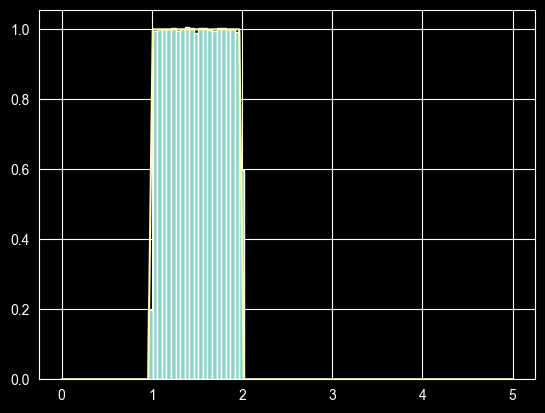

In [9]:
t = np.linspace(0.0, 5.0, 100)
plt.hist(answer_1_1, bins=t, density=True)
plt.plot(t, 1.0 * ((1.0 <= t) & (t <= 2.0)))

In [10]:
assert answer_1_1.shape == (1000000,), 'Ошибка, переделайте или пропускайте задание'
assert stats.kstest(answer_1_1, lambda t: np.where(1.0 <= t, np.where(t >= 2.0, 1.0, (t - 1)), 0.0)).pvalue > 0.1, \
    'Ошибка, переделайте или пропускайте задание'
ok.add('1.1')

#### 1.2. Нормально распределённая случайная величина

**Задача:** сгенерируйте **100000** наблюдений случайной величины $x \sim \mathcal{N}(10, \frac{1}{2})$.


In [11]:
rng_1_2 = np.random.RandomState(123)

In [12]:
answer_1_2 = rng_1_2.normal(loc=10, scale=0.5, size=100000)

Посмотрим на плотность:

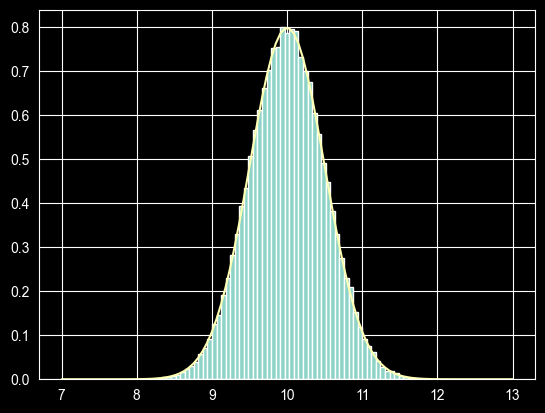

In [13]:
t = np.linspace(7.0, 13.0, 100)
plt.hist(answer_1_2, bins=t, density=True)
plt.plot(t, 1 / np.sqrt(2 * np.pi * 0.5 ** 2) * np.exp(-(t - 10.0) ** 2 / (2 * 0.5 ** 2)))

In [14]:
assert answer_1_2.shape == (100000,), 'Ошибка, переделайте или пропускайте задание'
assert stats.normaltest(answer_1_2).pvalue > 0.1, 'Ошибка, переделайте или пропускайте задание'
ok.add('1.2')

#### 1.3. Случайная величина, распределённая по заданному закону


**Задача:** сгенерируйте **100000** наблюдений случайной величины $x \sim F$, где распредление $F$ задано функцией распределения.


Функция распределения:

$$
P(X \le x) = F(x) = 1 - \exp(-12 x) / 3
$$


In [15]:
rng_1_3 = np.random.RandomState(123)

Ваши рассуждения...


In [16]:
answer_1_3 = -np.log(3 * (1 - rng_1_3.uniform(0, 1, size=100000))) / 12

Посмотрим на реальную плотность и эмпирическую оценку:

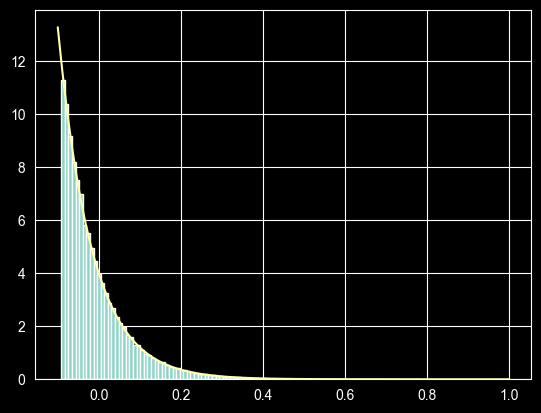

In [17]:
plt.hist(answer_1_3, bins=100, density=True)
t = np.linspace(-0.1, 1.0, 100)
plt.plot(t, 4 * np.exp(-12 * t))

In [18]:
assert answer_1_3.shape == (100000,), 'Ошибка, переделайте или пропускайте задание'
assert stats.kstest(answer_1_3, lambda t: 1 - np.exp(-12 * t) / 3).pvalue > 0.1, 'Ошибка, переделайте или пропускайте задание'
ok.add('1.3')

### 2. Построение модели (функция одной переменной)



Импорты для следующих заданий:

In [368]:
from sklearn.base import BaseEstimator, RegressorMixin

# на случай, если версия sklearn отличается очень существенно используем такой хак:
try:
    from sklearn.base import _fit_context
    from sklearn.utils._param_validation import StrOptions
except:
    _fit_context = lambda **kwargs: lambda fn: fn
    StrOptions = lambda _: None

try:
    from sklearn.utils import check_X_y
except:
    check_X_y = lambda X, y: None


Здесь генерируются искусственные данные для обучения (их **нельзя изменять**):

In [369]:
one_feature_X_train = np.linspace(0.0, 10.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 1))
one_feature_y_train = one_feature_X_train[:, 0] ** 2 + 1.0

one_feature_X_test = np.linspace(1.0, 15.0, 100).reshape((5, 5, 4)).transpose(2, 0, 1).reshape((-1, 1))
one_feature_y_test = one_feature_X_test[:, 0] ** 2 + 1.0

print('one_feature_X_train shape:', one_feature_X_train.shape)
print('one_feature_y_train shape:', one_feature_y_train.shape)

print('one_feature_X_test shape:', one_feature_X_test.shape)
print('one_feature_y_test shape:', one_feature_y_test.shape)

one_feature_X_train shape: (1000, 1)
one_feature_y_train shape: (1000,)
one_feature_X_test shape: (100, 1)
one_feature_y_test shape: (100,)


#### 2.0. Оптимальная константа


**Задача:** реализуйте модель, приближающую заданную функцию оптимальной константой, с точки зрения среднеквадратичной ошибки (MSE) или среднего абсолютного отклонения (MAD), в зависимости от параметра `loss`.

*По конвенции scikit-learn, все атрибуты, определяемые в процессе обучения (в методе `fit`) должны иметь `_` (нижнее подчёркивание) на конце или в начале. Например, если требуется сохранить возвращаемую константу, ей можно дать имя `self.constant_`, либо `self._constant` (если она не должна быть доступна пользователю, что скорей всего не требуется), но имён вроде `self.constant` надо избегать (см. [документацию](https://scikit-learn.org/stable/developers/develop.html#estimated-attributes)).*

**Поменяйте код в методах `fit`, `predict`**:

In [370]:
class ConstantRegressor(RegressorMixin, BaseEstimator):
    _parameter_constraints: dict = {
        "loss": [StrOptions({"mse", "mae"})],
    }
    def __init__(self, loss: str = 'mse'):
        self.loss = loss

    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y):
        check_X_y(X, y)

        if self.loss == 'mse':
            ... # ваш код
        elif self.loss == 'mae':
            ... # ваш код
        else:
            raise NotImplementedError()
        return self  # всегда возвращаем `self` из метода `fit`

    def predict(self, X):
        return # ваш код


Создаём модели, затем обучаем (этот код **менять не надо**):

In [371]:
constant_regressors = {
    loss: ConstantRegressor(loss=loss)
    for loss in ('mae', 'mse')
}

for model in constant_regressors.values():
    model.fit(one_feature_X_train, one_feature_y_train)


Обученные модели лежат в словаре, попробуем получить предсказания и посмотрим их размерности:

In [372]:
print(
    constant_regressors['mse'].predict(one_feature_X_train).shape,
    constant_regressors['mae'].predict(one_feature_X_train).shape,
    '|',
    constant_regressors['mse'].predict(one_feature_X_test).shape,
    constant_regressors['mae'].predict(one_feature_X_test).shape
)

(1000,) (1000,) | (100,) (100,)


Проверки, что задание выполнено верно:

In [373]:
for loss, model in constant_regressors.items():
    assert isinstance(model, ConstantRegressor), 'Модель должна быть нужного класса'
    predictions = model.predict(one_feature_X_test)
    assert predictions.shape[0] == one_feature_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
    assert np.allclose(predictions[:-1], predictions[1:]), 'Модель должна возвращать константу'
    if not np.allclose(predictions[0], {'mae': 26.0000250500751, 'mse': 34.35001668335001}[loss]):
        raise ValueError(
            f'Константа должна быть оптимальной с точки зрения функции потерь. Это не так для {loss!r}'
        )

ok.add('2.0')

#### 2.1. Оптимальная ступенчатая функция


**Задача:** реализуйте модель, приближающую заданную функцию оптимальной ступенчатой функцией, с точки зрения среднеквадратичной ошибки (MSE).

Ступенчатая функция реализуется следующим образом:

$$
f(x) = \begin{cases}
a, & x \le \theta \\
b, & x > \theta.
\end{cases}
$$

Здесь генерируются искусственные данные для обучения (**нелья менять**):

In [374]:
step_X_train = np.linspace(-10.0, 20.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 1))
step_y_train = np.tanh((-step_X_train[:, 0] + 5.0) * 10.0) + 1.0

step_X_test = np.linspace(1.0, 15.0, 100).reshape((5, 5, 4)).transpose(2, 0, 1).reshape((-1, 1))
step_y_test = np.tanh((-step_X_test[:, 0] + 5.0) * 10.0) + 1.0


Реализация модели:

In [375]:
class OneDimStepFunctionRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        check_X_y(X, y)
        assert X.shape[1] == 1
        
        # ваш код
        return self

    def predict(self, X):
        return # ваш код


Создаём модель, затем обучаем:

In [376]:
step_regressor = OneDimStepFunctionRegressor()
step_regressor.fit(step_X_train, step_y_train)

OneDimStepFunctionRegressor()

In [377]:
# ваш код для проверки модели, если требуется

Посмотрим на обучающие данные и предсказываемые значения:

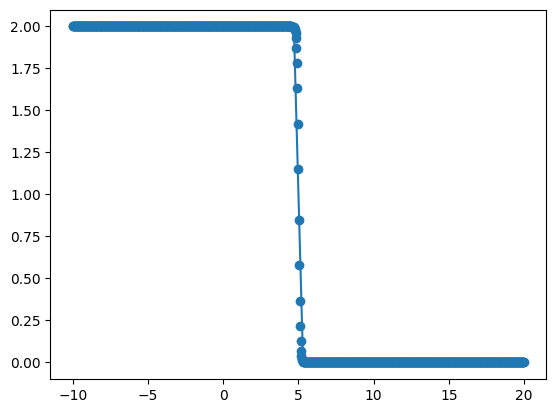

In [378]:
plt.scatter(step_X_train[:, 0], step_y_train)
t = np.linspace(-10., 20.)
plt.plot(t, step_regressor.predict(t[:, np.newaxis]), c='orange')

Проверки, что задание выполнено верно:

In [379]:
assert isinstance(step_regressor, OneDimStepFunctionRegressor), 'Модель должна быть нужного класса'
predictions = step_regressor.predict(step_X_test)
assert predictions.shape[0] == step_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert np.allclose(np.unique(predictions), np.array([0.0, 2.0]), atol=1.e-1), \
    'Ступеньки должны быть оптимальными с точки зрения MSE'

ok.add('2.1')

#### 2.2. Линейная функция


**Задача:** реализуйте модель, приближающую заданную функцию *одной переменной* оптимальной линейной функцией *одной переменной*, с точки зрения среднеквадратичной ошибки (MSE).

**В этом задании нельзя использовать готовые модели, функции решения систем линейных уравнений, и т.п.**

Найдите оптимальный коэффициент $w$ и смещение $b$, минимизируя квадратичную ошибку:

$$
f(x) = w \cdot x + b, \quad x, w, b \in \mathbb{R}.
$$

$$
L(w, b) = \sum_{i=1}^{N} (w \cdot x_i + b - y_i)^2 \to \min_{w, b},
$$

где $\{ (x_1, y_1), \dots , (x_N, y_N) \}$ – обучающая выборка.

*Задача может оказаться не очень простой, поэтому рекомендуется сначала сделать предобработку данных.**
А именно, **сдвинем $x$**, т.е. $\xi = x - s$, чтобы $\sum_{i=1}^{N} \xi_i = 0$.
Решите задачу для предобработанных данных, и не забудьте каждый раз сдвигать признаки, и в `fit`, и в `transform`.

Выпишите (здесь или на листочке) чему равны оптимальные значения $w, b$:

... ваши рассуждения (если требуется)

Здесь генерируются искусственные данные для обучения (**нельзя изменять**):

In [380]:
lin_X_train = np.linspace(-10.0, 20.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 1))
lin_y_train = -lin_X_train[:, 0] * 10.0 + 1.0

lin_X_test = np.linspace(1.0, 15.0, 100).reshape((5, 5, 4)).transpose(2, 0, 1).reshape((-1, 1))
lin_y_test = -lin_X_test[:, 0] * 10.0 + 1.0


Реализация модели:

In [381]:
class OneDimLinearFunctionRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        check_X_y(X, y)
        assert X.shape[1] == 1
        
        # ваш код
        return self

    def predict(self, X):
        # ваш код
        return # ваш код


Создаём модель, затем обучаем:

In [382]:
lin_regressor = OneDimLinearFunctionRegressor()
lin_regressor.fit(lin_X_train, lin_y_train)

OneDimLinearFunctionRegressor()

In [383]:
# ваш код для проверки модели, если требуется

Модель на графике должна быть линейной и проходить через точки обучающей выборки:

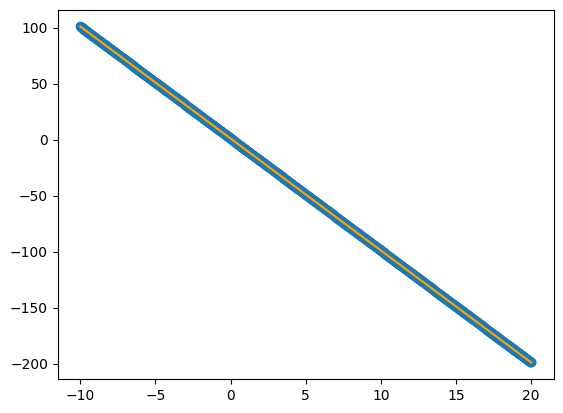

In [384]:
plt.scatter(lin_X_train[:, 0], lin_y_train)
t = np.linspace(-10., 20.)
plt.plot(t, lin_regressor.predict(t[:, np.newaxis]), c='orange')

Проверки, что задание выполнено верно:

In [385]:
assert isinstance(lin_regressor, OneDimLinearFunctionRegressor), 'Модель должна быть нужного класса'
predictions = lin_regressor.predict(lin_X_test)
assert predictions.shape[0] == lin_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert len(np.unique(predictions)) >= 100, 'Предсказания для различных точек должны отличаться'
assert np.allclose(predictions, lin_y_test, atol=1.e-3), \
    'Ошибка на тестовой выборке должна быть меньше, скорей всего ошибку видно на графике выше'

ok.add('2.2')

### 3. Построение модели (функция многих переменных)



#### 3.1. Оптимальная ступенчатая функция


**Задача:** реализуйте модель, приближающую заданную функцию оптимальной ступенчатой функцией, с точки зрения среднеквадратичной ошибки (MSE). На вход подаётся вектор: $x = (x^{(1)}, \dots, x^{(d)}) \in \mathbb{R}^d$,
функция должна быть ступенчатой по одному из признаков. Следует выбрать тот признак, который позволит наиболее сильно снизить ошибку.

В данном случае ступенчатая функция выглядит следующим образом:

$$
f(x) = \begin{cases}
a, & x^{(k)} \le \theta \\
b, & x^{(k)} > \theta,
\end{cases}
$$

где $\theta$ – пороговое значение, $k$ – номер признака, по которому строится ступенька.

*В этом задании разрешено использовать циклы по признакам, а также обращаться к `OneDimStepFunctionRegressor` (создавать новые экземпляры, не копируя код).*

Здесь генерируются искусственные данные для обучения (**нельзя менять**):

In [386]:
ndim_step_X_train = np.linspace(-10.0, 20.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 8))
ndim_step_y_train = np.tanh((-ndim_step_X_train[:, 6] + 5.0) * 10.0) + 1.0 + np.sin(ndim_step_X_train[:, 0]) / 10

ndim_step_X_test = np.linspace(1.0, 15.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 8))
ndim_step_y_test = np.tanh((-ndim_step_X_test[:, 6] + 5.0) * 10.0) + 1.0 + np.sin(ndim_step_X_test[:, 0]) / 10


Реализация модели:

In [387]:
class StepFunctionRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        check_X_y(X, y)
        
        # ваш код
        return self

    def predict(self, X):
        return # ваш код


Создаём модель, затем обучаем:

In [388]:
ndim_step_regressor = StepFunctionRegressor()
ndim_step_regressor.fit(ndim_step_X_train, ndim_step_y_train)

StepFunctionRegressor()

In [389]:
# ваш код для проверки модели, если требуется

Посмотреть на функцию 8 аргументов на графике не очень просто, поэтому посмотрим на MSE:

In [390]:
print('Error on train:', np.mean((ndim_step_regressor.predict(ndim_step_X_train) - ndim_step_y_train) ** 2))
print('Error on test:', np.mean((ndim_step_regressor.predict(ndim_step_X_test) - ndim_step_y_test) ** 2))

Error on train: 0.006326234752950033
Error on test: 0.007564326803552625


Проверки, что задание выполнено верно:

In [391]:
assert isinstance(ndim_step_regressor, StepFunctionRegressor), 'Модель должна быть нужного класса'
predictions = ndim_step_regressor.predict(ndim_step_X_test)
assert predictions.shape[0] == ndim_step_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert np.allclose(np.unique(predictions), np.array([0.0, 2.0]), atol=1.e-1), \
    'Ступеньки должны быть оптимальными с точки зрения MSE'

ok.add('3.1')

#### 3.2. Линейная функция (d переменных)


**Задача:** реализуйте модель, приближающую заданную функцию оптимальной линейной функцией, с точки зрения среднеквадратичной ошибки (MSE).

В этом задании **можно использовать** готовые функции решения систем линейных уравнений, но **не готовые модели**.

Модель выглядит следующим образом:

$$
f(x) = w^T x + b, \quad w, x \in \mathbb{R}^{d}, b \in \mathbb{R}.
$$


Для решения данной задачи рекомендуется рассмотреть альтернативную формулировку модели:

$$
f(x) = \tilde{w}^T \tilde{x},
$$

где $\tilde{w} = (w^{(1)}, \dots, w^{(d)}, b)$, $\tilde{x} = (x^{(1)}, \dots, x^{(d)}, 1)$.

Тогда задачу можно записать следующим образом:

$$
\lVert \widetilde{X} \tilde{w} - y \rVert^2 \to \min_{\tilde{w}},
$$

где $\widetilde{X} \in \mathbb{R}^{N \times (d + 1)}$ – составлена из векторов признаков обучающей выборки (с дописанной в конец 1, как показано выше.

Для решения этой задачи (т.н. Least Squares), используйте функцию `np.linalg.lstsq`.


Здесь генерируются искусственные данные для обучения (**нельзя изменять**):

In [392]:
ndim_lin_X_train = np.linspace(-10.0, 20.0, 5000).reshape((50, 25, 4)).transpose(2, 0, 1).reshape((-1, 8))
ndim_lin_coef = np.array([1., 2., -1., -2., 3., 4., 5., 0.])
ndim_lin_y_train = -ndim_lin_X_train @ ndim_lin_coef + 1.0

ndim_lin_X_test = np.linspace(1.0, 15.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 8))
ndim_lin_y_test = -ndim_lin_X_test @ ndim_lin_coef + 1.0


Реализация модели:

In [393]:
class LinearFunctionRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        check_X_y(X, y)
        
        # ваш код
        return self

    def predict(self, X):
        return # ваш код


Создаём модель, затем обучаем:

In [394]:
ndim_lin_regressor = LinearFunctionRegressor()
ndim_lin_regressor.fit(ndim_lin_X_train, ndim_lin_y_train)

LinearFunctionRegressor()

In [395]:
# ваш код для проверки модели, если требуется

In [396]:
print('Error on train:', np.mean((ndim_lin_regressor.predict(ndim_lin_X_train) - ndim_lin_y_train) ** 2))
print('Error on test:', np.mean((ndim_lin_regressor.predict(ndim_lin_X_test) - ndim_lin_y_test) ** 2))

Error on train: 2.4788724112419055e-27
Error on test: 0.0039052154340011775


Проверки, что задание выполнено верно:

In [397]:
assert isinstance(ndim_lin_regressor, LinearFunctionRegressor), 'Модель должна быть нужного класса'
predictions = ndim_lin_regressor.predict(ndim_lin_X_test)
assert predictions.shape[0] == ndim_lin_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert len(np.unique(predictions)) >= 125, 'Предсказания для различных точек должны отличаться'
assert np.allclose(predictions, ndim_lin_y_test, atol=1.e-1), \
    'Ошибка на тестовой выборке должна быть меньше'

ok.add('3.2')

## Итоги

In [19]:
print(f'Выполнены задания: {ok}')
print(f'Осталось: {all_tasks - ok}')
print(f'Выполнено: {len(ok)}. Не выполнено: {len(all_tasks - ok)}')

Выполнены задания: {'1.2', '1.3', '1.1', '1.0'}
Осталось: {'3.1', '2.0', '3.2', '2.2', '2.1'}
Выполнено: 4. Не выполнено: 5
